----------------
# １．ライブラリのインポート

In [1]:
import time
import warnings
from pathlib import Path
from typing import Literal

# 可視化の設定
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from numpy.typing import NDArray
from rich import print
from rich.console import Console
from rich.panel import Panel
from rich.table import Table

# Scikit-learn関連
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

from src.allocator import estimate_y_var, OptimalAllocator, ProportionalAllocator, estimate_y_rmse
from src.estimator import (
    COSSEstimator,
    CUPEDEstimator,
    MLRATEEstimator,
    NormalEstimator,
    RandomEstimator,
    SequentialForwardSelectionVarEstimator,
    OMTEstimator,
    CARTEstimator,
    KMeansDTEstimator,
)

# Ignore ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

plt.style.use("ggplot")

--------
# ２．実験設定

### 実験設定

In [2]:
### 実験データの設定 ###
TARGET = "購入金額"
features_list_con = ["年齢", "年収"]  # 連続変数のリスト
features_list_cat = ["性別", "学歴", "地域", "会員ランク", "購入頻度"]  # 質的変数のリスト
features_list = features_list_con + features_list_cat
variables_list = [TARGET] + features_list_con + features_list_cat

# 特徴量名の翻訳マップ
translation_map = {
    "purchase_amount": "購入金額",
    "age": "年齢",
    "income": "年収",
    "gender": "性別",
    "education": "学歴",
    "region": "地域",
    "loyalty_status": "会員ランク",
    "purchase_frequency": "購入頻度"
}

value_translation_map = {
    "gender": {"Male": "男性", "Female": "女性"},
    "education": {"HighSchool": "高校", "College": "専門", "Bachelor": "学士", "Masters": "修士"},
    "region": {"North": "北", "South": "南", "East": "東", "West": "西"},
    "loyalty_status": {"Regular": "レギュラー", "Silver": "シルバー", "Gold": "ゴールド"},
    "purchase_frequency": {"frequent": "高", "occasional": "中", "rare": "低"}
}

### 実験設定 ###
### シード ###
np.random.seed(42)
RANDOM_STATE = 42  # 乱数シード
SAMPLE_SIZE = 100  # 標本サイズ
N_TRIALS = 10000  # 試行回数（標本平均を求める回数）

### 可視化 ###
TITLE_SIZE = 20
LABEL_SIZE = 15
TICK_SIZE = 12.5
LEGEND_SIZE = 12.5

# 入力データのディレクトリ
DATA_PATH = Path("./data/") / "customer"
# 出力データのディレクトリ
OUTPUT_DIR = Path("./outputs") / "customer" / str(SAMPLE_SIZE)
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

-----------
# ３．データの前処理

### データ読み込み

In [3]:
df_customer = pd.read_csv(DATA_PATH / "customer_data.csv")

In [4]:
for col, mapping in value_translation_map.items():
    if col in df_customer.columns:
        df_customer[col] = df_customer[col].replace(mapping)

# 3. カラム名を日本語に置換
df_customer = df_customer.rename(columns=translation_map)

df_customer_raw = df_customer.copy()

df_customer['性別'] = df_customer['性別'].map({'男性': 0, '女性': 1})

# 1-1. 質的変数のリストから「性別」を除外してOne-hotエンコーディングを適用
features_list_cat_ohe = [f for f in features_list_cat if f != "性別"]
df_customer_encoded = pd.get_dummies(df_customer, columns=features_list_cat_ohe)

# 1-2. エンコーディング後の列名リストを再構成
# 「性別」はそのまま数値カラムとして残っているので、features_list_con（連続変数）と同様に扱います
binary_feature_names = [col for col in df_customer_encoded.columns if any(col.startswith(f + '_') for f in features_list_cat_ohe)]

# 性別を明示的に含める形でリストを作成
columns_list_encoded = features_list_con + ["性別"] + binary_feature_names
all_columns_encoded = [TARGET] + columns_list_encoded

# 1-3. 欠損値を除去
df_customer_clean_encoded = df_customer_encoded[all_columns_encoded].dropna()

# --- Step 2: 訓練用とテスト用に分割 ---

# 2-1. 訓練用とテスト用に分割
df_train_encoded, df_test_encoded = train_test_split(df_customer_clean_encoded, test_size=0.5, random_state=RANDOM_STATE)

# 2-2. 【CART / KMeans-DT用】One-hotエンコード済み・"非"標準化データ (DataFrame) を作成
df_X_train_encoded = df_train_encoded[columns_list_encoded].astype(int)
df_X_test_encoded = df_test_encoded[columns_list_encoded].astype(int)

rename_dict = {"性別": "性別_女性"}
df_X_train_encoded = df_X_train_encoded.rename(columns=rename_dict)
df_X_test_encoded = df_X_test_encoded.rename(columns=rename_dict)

columns_list_encoded = [rename_dict.get(c, c) for c in columns_list_encoded]

# 2-3. 【標準化が必要なモデル用】にNumPy配列に変換して標準化
X_train_encoded_np = df_X_train_encoded.to_numpy()
X_test_encoded_np = df_X_test_encoded.to_numpy()
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train_encoded_np)
X_test_std = sc.transform(X_test_encoded_np)

# 2-4. y (目的変数) を作成 (これは全モデル共通)
y_train = df_train_encoded[TARGET].to_numpy()
y_test = df_test_encoded[TARGET].to_numpy()
# --- Step 3: 【OMT用】One-hotエンコーディング "前" のデータを作成 ---
columns_list_original = features_list_con + features_list_cat
all_columns_original = [TARGET] + columns_list_original
df_customer_clean_original = df_customer_raw[all_columns_original].dropna()

# Step 2-1で作成したインデックスを使用して行を抽出する
df_train_original = df_customer_clean_original.loc[df_train_encoded.index]
df_test_original = df_customer_clean_original.loc[df_test_encoded.index]

df_X_train_original = df_train_original[columns_list_original]
df_X_test_original = df_test_original[columns_list_original]

print("--- データ準備完了 ---")
print("\n[OMT用データ (df_X_train_original)]")
print(df_X_train_original.head())
print("\n[CART/KMeans-DT/MLRATE用データ (df_X_train_encoded)]")
print(df_X_train_encoded.head())

--- データ準備完了 ---

[OMT用データ (df_X_train_original)]

年齢     年収  性別  学歴 地域  会員ランク 購入頻度
85797  37  31907  男性  学士  西  レギュラー    高
47354  26  45106  女性  専門  東   シルバー    中
6327   19  48297  女性  専門  東   ゴールド    高
93393  27   7647  女性  専門  南  レギュラー    高
19743  30  20187  男性  専門  北   シルバー    中

[CART/KMeans-DT/MLRATE用データ (df_X_train_encoded)]

年齢     年収  性別_女性  学歴_修士  学歴_学士  学歴_専門  学歴_高校  地域_北  地域_南  地域_東  地域_西  \
85797  37  31907      0      0      1      0      0     0     0     0     1   
47354  26  45106      1      0      0      1      0     0     0     1     0   
6327   19  48297      1      0      0      1      0     0     0     1     0   
93393  27   7647      1      0      0      1      0     0     1     0     0   
19743  30  20187      0      0      0      1      0     1     0     0     0   

       会員ランク_ゴールド  会員ランク_シルバー  会員ランク_レギュラー  購入頻度_中  購入頻度_低  購入頻度_高  
85797           0           0            1       0       0       1  
47354           0           1            0       1       0       0  
6327            1           0            0       0       0       1  
93393           0           0            1       0       0       1  
19743           0           1            0       1       0       0

In [5]:
# 実験方法
# クラスタリング
CLUSTERING_METHOD = "KMeans"  # "GMM" or "KMeans"
N_CLUSTERS = 5  # クラスタ数

# KMeans+DTの葉の数
MAX_LEAF_NODES = 5

# 特徴量選択
# True or No（特徴量数が MAXIMUM_FEATURES_TO_SELECT になるまで選ぶかいなか）
SELECT_MAXIMUM_FEATURES = False
MAXIMUM_FEATURES_TO_SELECT = 100  # 選択される最大の特徴量(特徴量選択ありの場合)

# 標本配分
ALLOCATION_METHODS = [
    ProportionalAllocator(),
    OptimalAllocator(m_value=1),
]

# OMT用のパラメータ設定
NUM_BINS = 4  # 連続値を離散化する際のビンの数
MAX_FEATURES_IN_RULE = 3  # 1つのルールに含める特徴量の最大数
MIN_COVERAGE = 1.0  # ルールがカバーすべきサンプルの最小割合
MIN_SAMPLES_IN_RULE = int(len(df_X_train_original) * 0.05)

print(f"MIN_SAMPLES_IN_RULE: {MIN_SAMPLES_IN_RULE}")

MIN_SAMPLES_IN_RULE: 2500

-------------
# ４．学習

### 推定手法ごとのインスタンスを作成

In [6]:
estimators = []

# Random
random = RandomEstimator(
    n_trials=N_TRIALS,
    sample_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)
estimators.append(random)

# CUPED
cuped = CUPEDEstimator(
    n_trials=N_TRIALS,
    sample_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)
estimators.append(cuped)

mlrate_gbdt = MLRATEEstimator(
    base_model=GradientBoostingRegressor(
        random_state=RANDOM_STATE,
    ),
    n_trials=N_TRIALS,
    sample_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)
estimators.append(mlrate_gbdt)

##############################
# 層化抽出手法
##############################
for allocator in ALLOCATION_METHODS:
    allocator_name = allocator.__str__()

    # OMTによる層化 (quantile)
    omt_quantile = OMTEstimator(
        allocator=allocator,
        sample_size=SAMPLE_SIZE,
        binning_strategy='quantile', # 分位数戦略
        num_bins=NUM_BINS, # 分割数を指定
        max_rules=N_CLUSTERS,
        max_features_in_rule=MAX_FEATURES_IN_RULE,
        categorical_variables=features_list_cat,
        min_coverage=MIN_COVERAGE,
        min_samples_in_rule=MIN_SAMPLES_IN_RULE,
        n_trials=N_TRIALS,
        random_state=RANDOM_STATE,
        verbose=True,
    )
    estimators.append(omt_quantile)

    # OMTによる層化 (optbinning)
    omt_optbinning = OMTEstimator(
        allocator=allocator,
        sample_size=SAMPLE_SIZE,
        binning_strategy='optbinning',
        categorical_variables=features_list_cat,
        max_rules=N_CLUSTERS,
        max_features_in_rule=MAX_FEATURES_IN_RULE,
        min_coverage=MIN_COVERAGE,
        min_samples_in_rule=MIN_SAMPLES_IN_RULE,
        n_trials=N_TRIALS,
        random_state=RANDOM_STATE,
        verbose=True,
        optb_max_n_prebins=20,                 # 事前分割の最大数
        optb_min_prebin_size=0.05,             # 各ビンの最小サンプル割合 (5%)
        optb_max_n_bins=20,                  # 最終的なビン数の上限（Noneは自動）
        optb_min_mean_diff=0.00,               # 隣接するビン間の平均値の最小差
        optb_max_pvalue=0.05,                  # ビンを結合しないための最大p値（統計的有意性の閾値）
        optb_gamma=0.0,                        # ビンのサイズを均一化する正則化項
        optb_monotonic_trend="auto",           # 目標値に対する単調性の制約 ("ascending", "descending" など)
    )
    estimators.append(omt_optbinning)

    # KMeans
    normal = NormalEstimator(
        n_clusters=N_CLUSTERS,
        allocator=allocator,
        sample_size=SAMPLE_SIZE,
        n_trials=N_TRIALS,
        clustering_method=CLUSTERING_METHOD,
        random_state=RANDOM_STATE,
    )
    estimators.append(normal)
    
    # KMeans + 決定木
    kmeans_dt = KMeansDTEstimator(
        n_clusters=N_CLUSTERS,
        allocator=allocator,
        sample_size=SAMPLE_SIZE,
        n_trials=N_TRIALS,
        random_state=RANDOM_STATE,
        max_leaf_nodes=MAX_LEAF_NODES, # max_depth から変更
    )
    estimators.append(kmeans_dt)

    # クラスタリング + 特徴量選択
    sfs_var = SequentialForwardSelectionVarEstimator(
        maximum_features_to_select=MAXIMUM_FEATURES_TO_SELECT,
        n_clusters=N_CLUSTERS,
        sample_size=SAMPLE_SIZE,
        n_trials=N_TRIALS,
        clustering_method=CLUSTERING_METHOD,
        select_maximum_features=SELECT_MAXIMUM_FEATURES,
        allocator=allocator,
        random_state=RANDOM_STATE,
    )
    estimators.append(sfs_var)
    
    # CART
    cart = CARTEstimator(
        allocator=allocator,
        sample_size=SAMPLE_SIZE,
        n_trials=N_TRIALS,
        max_leaf_nodes=N_CLUSTERS,  # 葉の数を他の手法のクラスタ数と合わせる
        random_state=RANDOM_STATE,
        min_samples_leaf=MIN_SAMPLES_IN_RULE,
    )
    estimators.append(cart)

### 標本配分手法ごとに訓練データで学習を実行

ここで、学習とは以下を表す
- CUPED
  - 最も相関の高い特徴量の選択
  - 係数 $\alpha$ の推定
- COSS
  - 最も相関の高い特徴量の選択
- 特徴量選択・層化手法
  - 特徴量選択
  - クラスタリング
  - 各層からの標本数の決定

In [7]:
console = Console()

train_results = []
for i, estimator in enumerate(estimators, start=1):
    estimator_name = str(estimator)
    
    console.print(
        Panel.fit(
            f"🎯 [bold cyan]{estimator_name}[/bold cyan]",
            title=f"🧠 Estimator {i}",
            style="blue",
        )
    )
    
    allocator = getattr(estimator, "allocator", None)
    allocator_name = allocator.__str__() if allocator is not None else "N/A"

    # 学習
    if estimator_name == "KMeans-DT":
        start = time.time()
        estimator.fit(X_train_std, y_train, X_orig=df_X_train_encoded)
        elapsed_time = time.time() - start

    elif "OMT(" in estimator_name:
        X_fit, y_fit = df_X_train_original, y_train
        start = time.time()
        estimator.fit(X_fit, y_fit)
        elapsed_time = time.time() - start
        
    elif estimator_name == "CART" or estimator_name == "MLRATE":
        X_fit, y_fit = df_X_train_encoded, y_train
        start = time.time()
        estimator.fit(X_fit, y_fit)
        elapsed_time = time.time() - start

    else:
        X_fit, y_fit = X_train_std, y_train
        start = time.time()
        estimator.fit(X_fit, y_fit)
        elapsed_time = time.time() - start

    # --- 決定木の画像保存 ---
    if estimator_name == "KMeans-DT":
        tree_filename = OUTPUT_DIR / f"decision_tree_{estimator_name}_{allocator_name}_{str(SAMPLE_SIZE)}.png"
        estimator.save_decision_tree(
            feature_names=columns_list_encoded,
            filename=str(tree_filename)
        ) 

    elif estimator_name == "CART":
        tree_filename = OUTPUT_DIR / f"decision_tree_{estimator_name}_{allocator_name}_{str(SAMPLE_SIZE)}.png"
        estimator.save_tree_png(
            feature_names=columns_list_encoded,
            filename=str(tree_filename)
        )

    elif "OMT(" in estimator_name:
        tree_filename = OUTPUT_DIR / f"decision_tree_{estimator_name}_{allocator_name}_{str(SAMPLE_SIZE)}.png"
        estimator.save_tree_png(
            filename=str(tree_filename)
            )

    # 結果の整理
    selected_features_index = getattr(estimator, "get_selected_features_index", lambda: None)()

    # estimatorに応じて使用する特徴量名リストを決定する
    if "OMT(" in estimator_name:
        current_feature_names = features_list
    else:
        current_feature_names = columns_list_encoded

    selected_features_name = (
        [current_feature_names[i] for i in selected_features_index]
        if selected_features_index is not None
        else None
    )

    max_correlation = getattr(estimator, "get_max_correlation", lambda: None)()
    score_history = getattr(estimator, "get_score_history", lambda: None)()

    # 結果を表形式で表示
    table = Table(show_header=False, box=None)
    table.add_row("📊 [bold yellow]Allocator:[/bold yellow]", str(allocator_name))
    table.add_row(
        "✅ [bold magenta]Selected Features Index:[/bold magenta]", str(selected_features_index)
    )
    table.add_row("📊 [bold yellow]Score History:[/bold yellow]", str(score_history))
    table.add_row("⏱️ [bold cyan]Elapsed Time:[/bold cyan]", f"{elapsed_time:.2f} sec")
    console.print(table)

    # 結果の保存
    train_results.append(
        {
            "allocator": allocator_name,
            "estimator": estimator_name,
            "selected_features": selected_features_index,
            "selected_features_name": selected_features_name,
            "max_correlation": max_correlation,
            "score_history": score_history,
            "elapsed_time": elapsed_time,
        }
    )
    console.print("=" * 60)

train_result_df = pd.DataFrame(train_results)
train_result_df.to_csv(
    OUTPUT_DIR / f"training_result_{str(SAMPLE_SIZE)}.csv", index=False
)

╭─ 🧠 Estimator 1 ─╮
│ 🎯 Random        │
╰──────────────────╯

📊 Allocator:                N/A      
 ✅ Selected Features Index:  None     
 📊 Score History:            None     
 ⏱️ Elapsed Time:              0.00 sec

============================================================

╭─ 🧠 Estimator 2 ─╮
│ 🎯 CUPED         │
╰──────────────────╯

📊 Allocator:                N/A      
 ✅ Selected Features Index:  [1]      
 📊 Score History:            None     
 ⏱️ Elapsed Time:              0.01 sec

...

============================================================

╭─ 🧠 Estimator 15 ─╮
│ 🎯 CART           │
╰───────────────────╯

--- CART Stratification Rules ---
|--- 年収 <= 27739.50
|   |--- 年収 <= 16173.50
|   |   |--- value: [3697.28]
|   |--- 年収 >  16173.50
|   |   |--- 年収 <= 21881.00
|   |   |   |--- value: [6674.76]
|   |   |--- 年収 >  21881.00
|   |   |   |--- value: [8683.62]
|--- 年収 >  27739.50
|   |--- 年収 <= 39246.50
|   |   |--- value: [11719.17]
|   |--- 年収 >  39246.50
|   |   |--- value: [15622.19]

---------------------------------
決定木を 'outputs\customer\100\decision_tree_CART_Optimal_100.png' に保存しました。


📊 Allocator:                Optimal  
 ✅ Selected Features Index:  None     
 📊 Score History:            None     
 ⏱️ Elapsed Time:              0.10 sec

============================================================

### 評価関数の推移

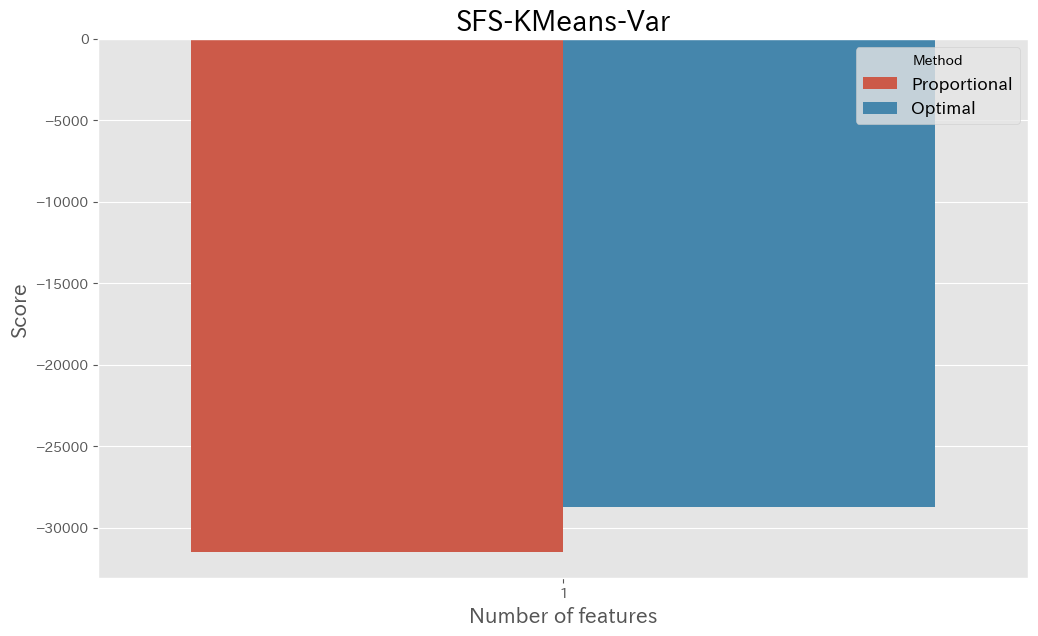

In [8]:
sfs_result_df = train_result_df[train_result_df["score_history"].notna()]

for estimator_name, gdf in sfs_result_df.groupby("estimator"):
    # 縦持ちに展開
    gdf["num_features"] = gdf["score_history"].map(lambda x: list(range(1, len(x) + 1)))
    gdf = gdf.explode(["score_history", "num_features"])

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=gdf, x="num_features", y="score_history", hue="allocator", dodge=True, ax=ax)
    ax.set_title(f"{estimator_name}", fontsize=TITLE_SIZE)
    ax.set_xlabel("Number of features", fontsize=LABEL_SIZE)
    ax.set_ylabel("Score", fontsize=LABEL_SIZE)
    ax.legend(
        title="Method",
        fontsize=TICK_SIZE,
    )

### 特徴量選択の結果

In [9]:
selection_result_df = train_result_df[train_result_df["selected_features"].notnull()][
    ["allocator", "estimator", "selected_features_name"]
]
selection_result_df

,allocator,estimator,selected_features_name
1,N/A,CUPED,[年収]
7,Proportional,SFS-KMeans-Var,[年収]
13,Optimal,SFS-KMeans-Var,[年収]


## 5.2 標本配分

In [10]:
# --- 1. ベースラインとなる単純無作為抽出(Random)のRMSEを計算 ---
# 訓練データとテストデータの真の平均を先に計算
y_train_true_mean = y_train.mean()
y_test_true_mean = y_test.mean()

# random推定器を使ってベースラインRMSEを計算
RMSE_RANDOM_TRAIN = random.predict(X_train_std, y_train, true_mean=y_train_true_mean)
RMSE_RANDOM_TEST = random.predict(X_test_std, y_test, true_mean=y_test_true_mean)

print(f"訓練データでのRMSE (Random) : {RMSE_RANDOM_TRAIN:.4f}")
print(f"テストデータでのRMSE (Random) : {RMSE_RANDOM_TEST:.4f}")

pred_results = []

for estimator in estimators:
    estimator_name = str(estimator)

    # allocatorをestimatorオブジェクトから直接取得する処理を先に行う
    allocator = getattr(estimator, "allocator", None)
    allocator_name = allocator.__str__() if allocator is not None else "N/A"
    
    # タイトル表示をestimatorごとに行う
    console.rule(f"[bold cyan]【{estimator_name}({allocator_name})】[/bold cyan]")
    estimator_result = {}

    # --- OMTモデルの処理 ---
    if "OMT(" in estimator_name:
        # 訓練データとテストデータのラベルを取得
        labels_train_unfiltered = estimator.labels_
        labels_test_unfiltered = estimator._assign_labels(df_X_test_original)

        for y_, labels_unfiltered_, random_rmse, true_mean, data_name in [
            (y_train, labels_train_unfiltered, RMSE_RANDOM_TRAIN, y_train_true_mean, "train"),
            (y_test, labels_test_unfiltered, RMSE_RANDOM_TEST, y_test_true_mean, "test"),
        ]:
            covered_mask = (labels_unfiltered_ != -1)
            
            if not np.any(covered_mask):
                rmse, variance, bias, rrr = np.nan, np.nan, np.nan, np.nan
                sample_size_each_cluster = None
            else:
                y_covered = y_[covered_mask]
                labels_covered = labels_unfiltered_[covered_mask]
                
                # sample_size_each_clusterは訓練データでのみ計算
                if data_name == 'train':
                    sample_size_each_cluster = allocator.solve(
                        y_covered, labels_covered, estimator.n_rules_, estimator.sample_size
                    )

                rmse = estimate_y_rmse(
                    sample_size_each_cluster=sample_size_each_cluster,
                    y=y_covered,
                    labels=labels_covered,
                    true_mean=true_mean,
                    n_trials=estimator.n_trials,
                    random_state=estimator.random_state,
                )

                rrr = (1 - (rmse / random_rmse)) * 100 if not np.isnan(rmse) else np.nan
            
            result_data = {
                "estimator": estimator_name, "allocator": allocator_name, "is_train": data_name == "train",
                "sample_size_each_cluster": sample_size_each_cluster, "rmse": rmse, "rrr": rrr
            }
            pred_results.append(result_data)
            estimator_result[data_name] = result_data

    # --- OMT以外のモデルの処理 ---
    else:
        if estimator_name in ["CART", "KMeans-DT", "MLRATE"]:
            X_train_to_use, X_test_to_use = df_X_train_encoded, df_X_test_encoded
        else:
            X_train_to_use, X_test_to_use = X_train_std, X_test_std

        for X_, y_, random_rmse, true_mean, data_name in [
            (X_train_to_use, y_train, RMSE_RANDOM_TRAIN, y_train_true_mean, "train"),
            (X_test_to_use, y_test, RMSE_RANDOM_TEST, y_test_true_mean, "test"),
        ]:
            rmse= estimator.predict(X_, y_, true_mean=true_mean)
            sample_size_each_cluster = getattr(estimator, "sample_size_each_cluster", None)
            rrr = (1 - (rmse / random_rmse)) * 100
            
            result_data = {
                "estimator": estimator_name, "allocator": allocator_name, "is_train": data_name == "train",
                "sample_size_each_cluster": sample_size_each_cluster, "rmse": rmse, "rrr": rrr
            }
            pred_results.append(result_data)
            estimator_result[data_name] = result_data

    # --- 結果テーブルの表示（全モデル共通） ---
    table = Table(title="Results", title_style="bold cyan")
    table.add_column("Metric", justify="left", style="bold yellow")
    table.add_column("Train", justify="right", style="green")
    table.add_column("Test", justify="right", style="red")
    table.add_row(
        "Sample Size Each Cluster",
        str(estimator_result["train"]["sample_size_each_cluster"]),
        str(estimator_result["test"]["sample_size_each_cluster"]),
    )
    table.add_row("RMSE", f"{estimator_result['train']['rmse']:.4f}", f"{estimator_result['test']['rmse']:.4f}")
    table.add_row("RMSE Reduction Rate", f"{estimator_result['train']['rrr']:.2f}%", f"{estimator_result['test']['rrr']:.2f}%")
    console.print(table)

pred_result_df = pd.DataFrame(pred_results)
pred_result_df.to_csv(OUTPUT_DIR / f"prediction_result_{str(SAMPLE_SIZE)}.csv", index=False)

訓練データでのRMSE (Random) : 484.8245

テストデータでのRMSE (Random) : 487.5529

───────────────────────────────────────────────── 【Random(N/A)】 ─────────────────────────────────────────────────

                     Results                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric                   ┃    Train ┃     Test ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Sample Size Each Cluster │     None │     None │
│ RMSE                     │ 484.8245 │ 487.5529 │
│ RMSE Reduction Rate      │    0.00% │    0.00% │
└──────────────────────────┴──────────┴──────────┘

───────────────────────────────────────────────── 【CUPED(N/A)】 ──────────────────────────────────────────────────

...

                     Results                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric                   ┃    Train ┃     Test ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Sample Size Each Cluster │     None │     None │
│ RMSE                     │ 477.7144 │ 476.1641 │
│ RMSE Reduction Rate      │    1.47% │    2.34% │
└──────────────────────────┴──────────┴──────────┘

─────────────────────────────────────────── 【SFS-KMeans-Var(Optimal)】 ───────────────────────────────────────────

                             Results                              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Metric                   ┃            Train ┃             Test ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Sample Size Each Cluster │ [30 15 25 11 19] │ [30 15 25 11 19] │
│ RMSE                     │         169.4185 │         170.4411 │
│ RMSE Reduction Rate      │           65.06% │           65.04% │
└──────────────────────────┴──────────────────┴──────────────────┘

──────────────────────────────────────────────── 【CART(Optimal)】 ────────────────────────────────────────────────

                             Results                              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Metric                   ┃            Train ┃             Test ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Sample Size Each Cluster │ [18 30 34  8 10] │ [18 30 34  8 10] │
│ RMSE                     │         173.7156 │         175.0434 │
│ RMSE Reduction Rate      │           64.17% │           64.10% │
└──────────────────────────┴──────────────────┴──────────────────┘

## 6.4 結果のプロット

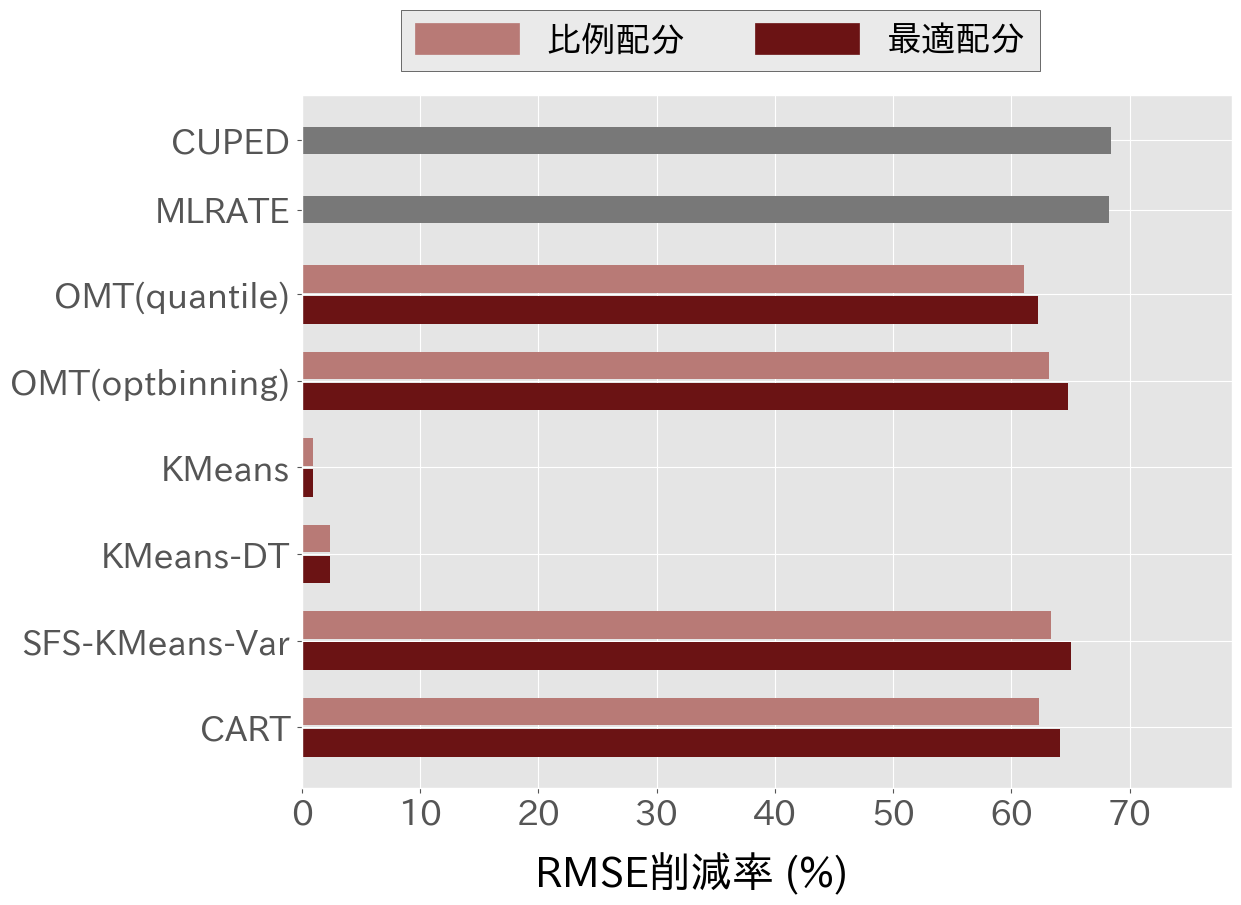

In [11]:
japanize_matplotlib.japanize()

# カラー設定
COLOR_OPTIMAL = "#6b1314"       # 最適標本配分 (濃い赤)
COLOR_PROPORTIONAL = "#b87a76"  # 比例配分 (薄い赤)
COLOR_SINGLE = "#787878"        # CUPEDなど単独の手法 (グレー)

# フォントサイズ設定
FONT_SIZE_LABEL = 25
FONT_SIZE_TICK = 25
FONT_SIZE_LEGEND = 25
FONT_SIZE_BAR_TEXT = 20
FONT_SIZE_AXIS_LABEL = 30

# 表示する手法の順序
estimator_order = [
    'CART',
    'SFS-KMeans-Var',
    'KMeans-DT', 
    'KMeans', 
    'OMT(optbinning)',
    'OMT(quantile)', 
    'MLRATE',
    'CUPED', 
]

# --- 1. データの前処理 (テストデータのみを抽出) ---
df_test = pred_result_df[~pred_result_df["is_train"]].copy()
df_test['allocator'] = df_test['allocator'].fillna('N/A').astype(str)

# estimatorとallocatorで集計
pivot_df = df_test.pivot_table(
    index='estimator', 
    columns='allocator', 
    values='rrr', 
    aggfunc='mean'
)

# --- 2. グラフ描画用データの構築 ---
y_positions = []
y_labels = []
bars_values = []
bars_y = []
bars_colors = []

current_y = 0

for est_name in estimator_order:
    if est_name not in pivot_df.index:
        continue
        
    row = pivot_df.loc[est_name]

    # 層化抽出（Optimal/Proportional）の有無を確認
    has_optimal = 'Optimal' in row and not pd.isna(row['Optimal'])
    has_proportional = 'Proportional' in row and not pd.isna(row['Proportional'])
    
    # --- パターンA: 層化抽出 (最適 or 比例 が存在する場合) ---
    if has_optimal or has_proportional:
        val_opt = row['Optimal'] if has_optimal else 0
        val_prop = row['Proportional'] if has_proportional else 0
        
        # 最適配分 (下側)
        bars_values.append(val_opt)
        bars_y.append(current_y)
        bars_colors.append(COLOR_OPTIMAL)
        
        # 比例配分 (上側)
        bars_values.append(val_prop)
        bars_y.append(current_y + 0.9) # 0.9ずらして配置
        bars_colors.append(COLOR_PROPORTIONAL)
        
        # Y軸ラベルの位置 (2本のバーの中間)
        y_positions.append(current_y + 0.45)
        y_labels.append(est_name)
        
        current_y += 2.5 # 次の手法との間隔
        
    # --- パターンB: 単独手法 (CUPEDなど) ---
    else:
        val = row['N/A'] if 'N/A' in row and not pd.isna(row['N/A']) else 0
        
        bars_values.append(val)
        bars_y.append(current_y + 0.4)
        bars_colors.append(COLOR_SINGLE)
        
        y_positions.append(current_y + 0.4)
        y_labels.append(est_name)
        
        current_y += 2.0

# --- 3. 描画の実行 ---
fig, ax = plt.subplots(figsize=(12, 9)) # 凡例スペース確保のため高さを少し広げました

ax.barh(bars_y, bars_values, height=0.8, color=bars_colors)

# 軸・刻みの設定
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=FONT_SIZE_LABEL)
ax.tick_params(axis='x', labelsize=FONT_SIZE_TICK)
ax.tick_params(axis='y', pad=5)

# X軸の表示範囲
if bars_values:
    limit = max(bars_values) * 1.15
    ax.set_xlim(0, limit)

# --- A. X軸ラベルを図の横幅の中心に配置 ---
# ax.set_xlabel の代わりに fig.text を使用
fig.text(
    0.45, 0, "RMSE削減率 (%)", 
    ha='center', fontsize=FONT_SIZE_AXIS_LABEL
)

# --- B. 凡例を図の横幅の中心に配置 ---
legend_handles = [
    plt.Rectangle((0,0), 1, 1, color=COLOR_PROPORTIONAL),
    plt.Rectangle((0,0), 1, 1, color=COLOR_OPTIMAL)
]

# bbox_to_anchor の座標系を fig.transFigure にすることで図全体に対する位置指定が可能
leg = ax.legend(
    legend_handles, 
    ["比例配分", "最適配分"], 
    fontsize=FONT_SIZE_LEGEND, 
    loc="lower center",
    bbox_to_anchor=(0.45, 1.01),   # 図の上部中央
    ncol=2, 
    frameon=True,
    edgecolor="black",
    fancybox=False,
    handleheight=1,              # 凡例のマークの高さを調整
    handlelength=3,              # 凡例のマークの長さを調整
)

plt.show()

# MIN_COVERAGEを変えた比較

True mean (TRAIN population): 9622.851120

True mean (TEST population) : 9646.730560

実験のセットアップを開始します。

───────────────────────────────────────────── Allocator: Proportional ─────────────────────────────────────────────

────────────────────────────────────── Strategy: quantile, Min Coverage: 1.0 ──────────────────────────────────────

...

───────────────────────────────────── Strategy: optbinning, Min Coverage: 0.8 ─────────────────────────────────────


[OptBinning] Table for Variable: '年齢'
                Bin  Count  Count (%)          Sum          Std        Mean  \
0       (-inf, inf)  50000        1.0  481142556.0  4801.505345  9622.85112   
1           Special      0        0.0          0.0          NaN     0.00000   
2           Missing      0        0.0          0.0          NaN     0.00000   
Totals               50000        1.0  481142556.0               9622.85112   

           Min      Max  Zeros count          WoE   IV  
0       1118.0  26204.0            0      0.00000  0.0  
1          NaN      NaN            0  -9622.85112  0.0  
2          NaN      NaN            0  -9622.85112  0.0  
Totals  1118.0  26204.0            0  19245.70224  0.0  

[OptBinning] Table for Variable: '年収'
                         Bin  Count  Count (%)          Sum          Std  \
0            (-inf, 7837.50)   3175    0.06350    7097998.0   427.228157   
1        [7837.50, 10491.50)   2993    0.05986    9590646.0   518.105337   
2       [1049

- TRAIN: MSE=2366664.948139, Var=20426.153589, Bias=-1531.743710 (Bias^2=2346238.794550), mu_cov=8091.107410

- TEST:  MSE=2429803.153496, Var=20652.568823, Bias=-1552.143867 (Bias^2=2409150.584674), mu_cov=8094.586693

================================================================================
📊 論文用図表の出力処理を開始します。

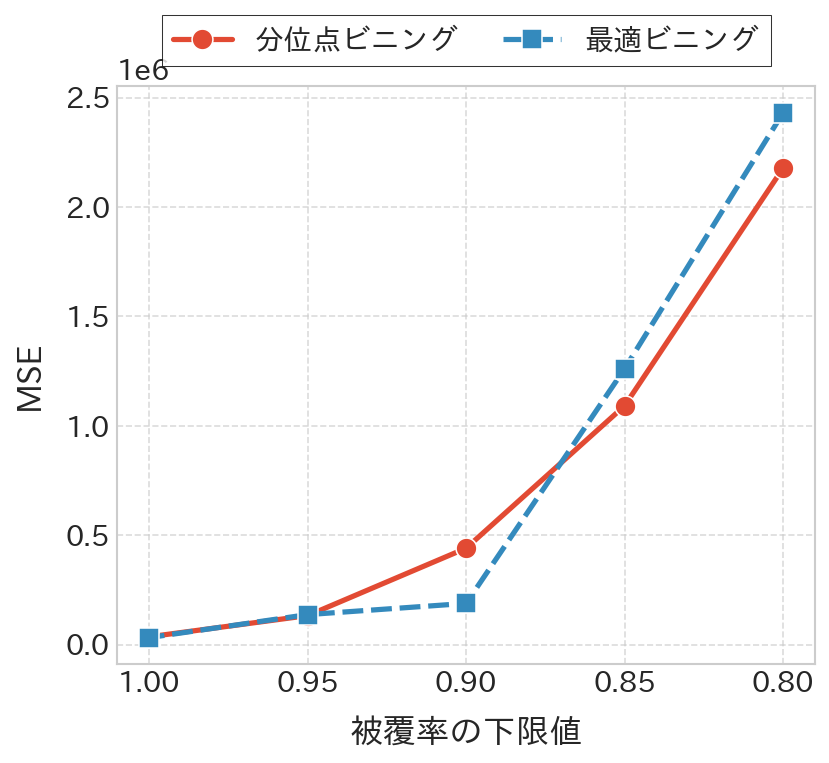

<Figure size 960x720 with 0 Axes>

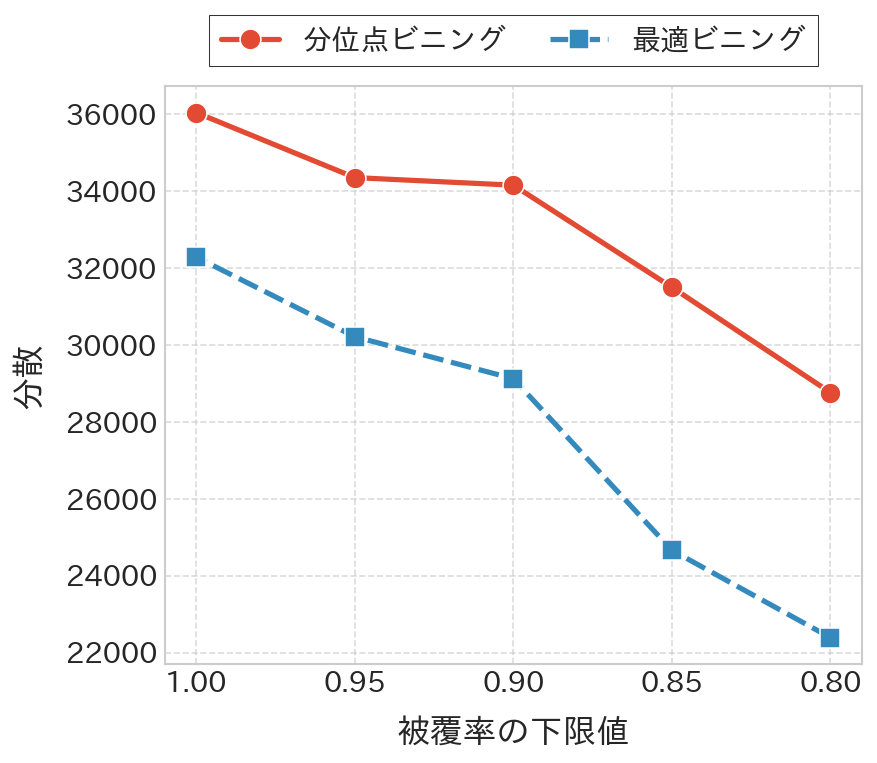

<Figure size 960x720 with 0 Axes>

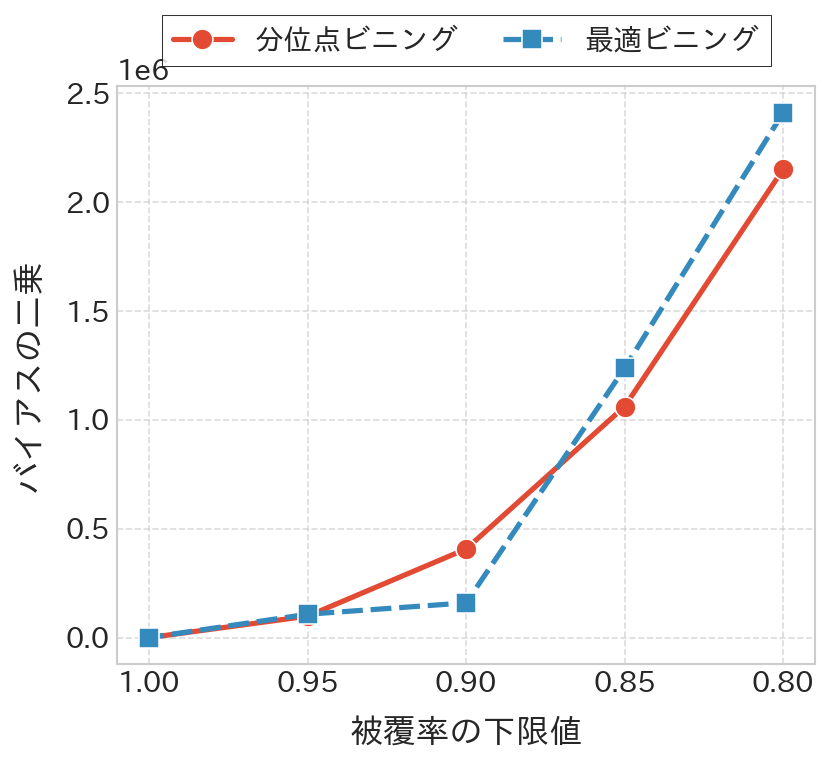

<Figure size 960x720 with 0 Axes>

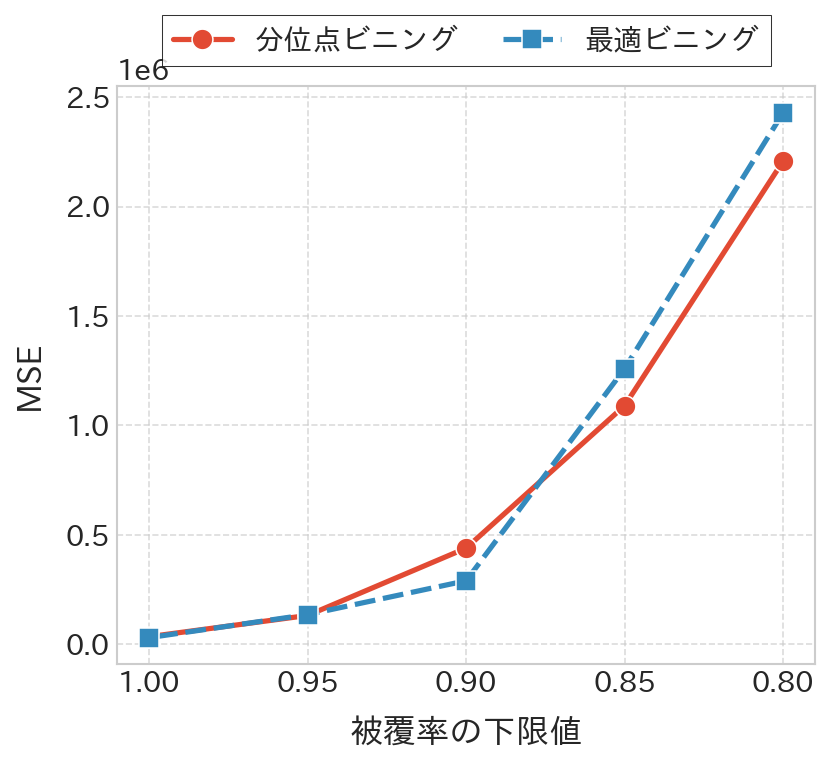

<Figure size 960x720 with 0 Axes>

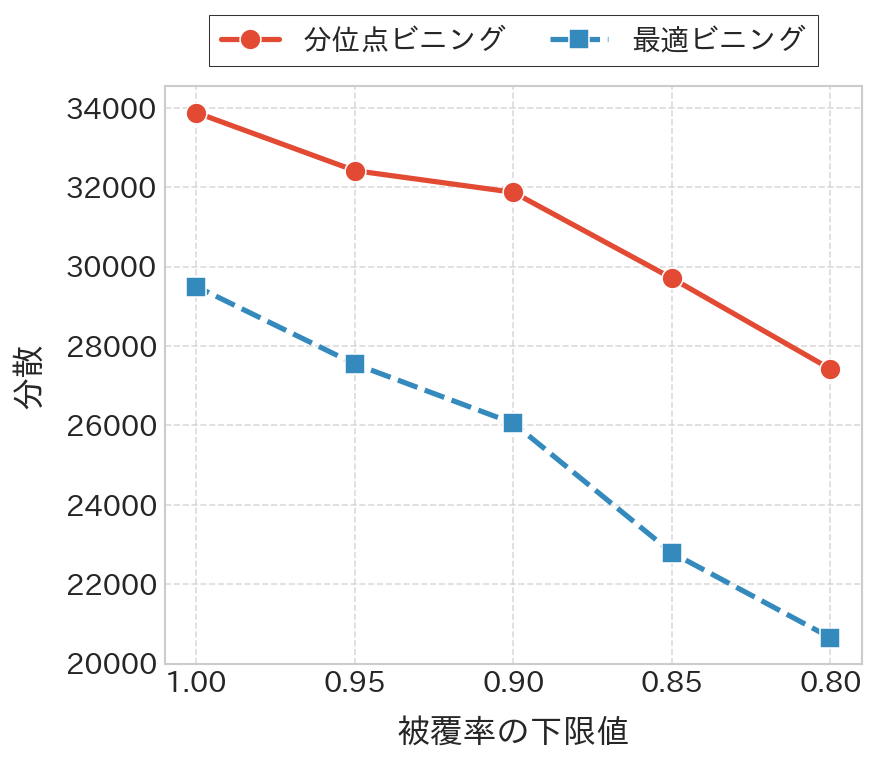

<Figure size 960x720 with 0 Axes>

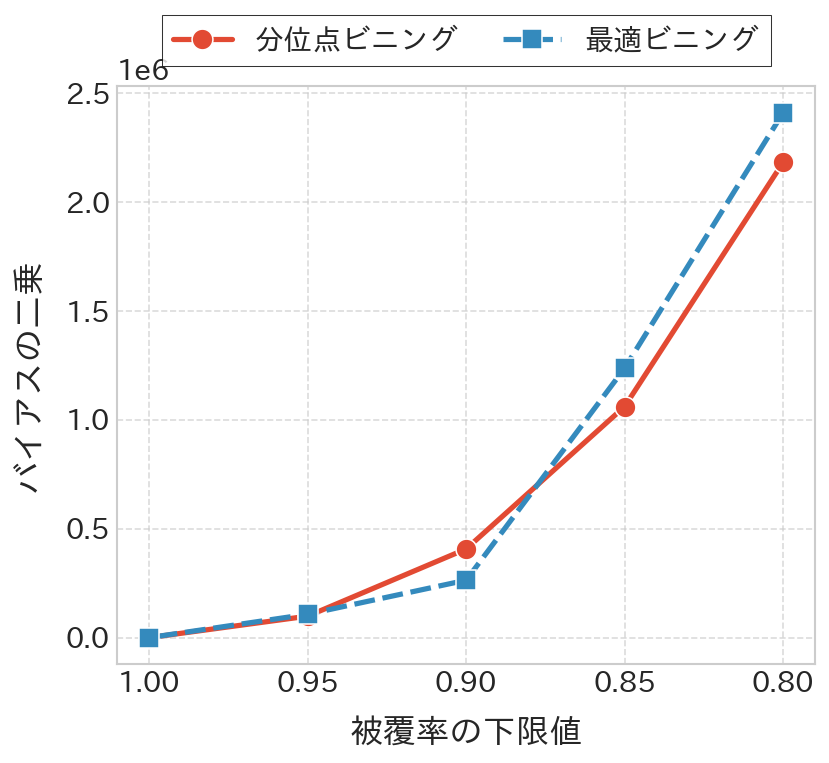

✅ 論文用図表（計6枚）を outputs\customer\100\thesis_figures に保存しました。

<Figure size 960x720 with 0 Axes>

In [12]:
# =============================================================================
#  OMT：Allocator × Binning × MIN_COVERAGE 実験 + 卒論向け可視化（完全版）
# =============================================================================

# =============================================================================
# --- 初期設定 ---
# =============================================================================
console = Console()
japanize_matplotlib.japanize()
plt.style.use("seaborn-v0_8-whitegrid")

# ======================================================================
# 0. 事前：母集団（train/test）の真の平均を計算（bias定義で使う）
# ======================================================================
mu_train_pop = float(y_train.mean())
mu_test_pop  = float(y_test.mean())

print(f"True mean (TRAIN population): {mu_train_pop:.6f}")
print(f"True mean (TEST population) : {mu_test_pop:.6f}")

# --- 1. 実験のセットアップ ---
print("\n実験のセットアップを開始します。")
min_coverage_values = [1.0, 0.95, 0.9, 0.85, 0.8]
binning_strategies = ['quantile', 'optbinning']
results = []

# ======================================================================
# 2. 実験ループ (標本配分方法 × ビニング戦略 × 被覆率)
# ======================================================================
for allocator in ALLOCATION_METHODS:
    allocator_name = allocator.__str__()
    console.rule(f"[bold red]Allocator: {allocator_name}[/bold red]")

    for binning_strategy in binning_strategies:
        for min_coverage in min_coverage_values:
            console.rule(f"[bold]Strategy: {binning_strategy}, Min Coverage: {min_coverage}[/bold]")

            omt_params = {
                "allocator": allocator,
                "sample_size": SAMPLE_SIZE,
                "binning_strategy": binning_strategy,
                "num_bins": NUM_BINS,
                "max_rules": N_CLUSTERS,
                "max_features_in_rule": MAX_FEATURES_IN_RULE,
                "min_coverage": min_coverage,
                "min_samples_in_rule": MIN_SAMPLES_IN_RULE,
                "n_trials": N_TRIALS,
                "random_state": RANDOM_STATE,
                "verbose": True,
            }

            # strategy が 'optbinning' の場合のみ、詳細パラメータを追加
            if binning_strategy == 'optbinning':
                omt_params.update({
                    "optb_max_n_prebins": 20,
                    "optb_min_prebin_size": 0.05,
                    "optb_max_n_bins": 20,
                    "optb_min_mean_diff": 0.00,
                    "optb_max_pvalue": 0.05,
                    "optb_gamma": 0.0,
                    "optb_monotonic_trend": "auto",
                })

            omt = OMTEstimator(**omt_params)

            try:
                omt.fit(df_X_train_original, y_train)

                actual_coverage = np.nan
                if hasattr(omt, "actual_coverage_rate_"):
                    actual_coverage = float(omt.actual_coverage_rate_)

                result_row = {
                    "allocator": allocator_name,
                    "binning_strategy": binning_strategy,
                    "min_coverage": float(min_coverage),
                    "actual_coverage": actual_coverage,
                }

                # ======================================================
                # 3. TRAIN: covered に限定して bias / variance / mse
                # ======================================================
                labels_train_all = omt.labels_
                covered_mask_train = (labels_train_all != -1)

                mse_train = variance_train = bias_train = np.nan
                sample_size_each_cluster = None

                if not np.any(covered_mask_train):
                    print("  - TRAIN: N/A (カバーされた訓練サンプルなし)")
                else:
                    y_train_cov = y_train[covered_mask_train]
                    labels_train_cov = labels_train_all[covered_mask_train]

                    # (A) selection bias（除外によるbias）：母集団平均との差
                    mu_train_cov = float(y_train_cov.mean())
                    bias_train = mu_train_cov - mu_train_pop

                    if omt.n_rules_ > 0:
                        # (B) 配分（covered の strata に対して）
                        sample_size_each_cluster = omt.sample_size_each_cluster

                        # (C) variance（covered 集団で抽出）
                        variance_train = float(
                            estimate_y_var(
                                sample_size_each_cluster,
                                y_train_cov,
                                labels_train_cov,
                                n_trials=N_TRIALS,
                                random_state=RANDOM_STATE
                            )
                        )

                        # (D) mse
                        mse_train = float(bias_train**2 + variance_train)

                        print(
                            f"  - TRAIN: MSE={mse_train:.6f}, "
                            f"Var={variance_train:.6f}, "
                            f"Bias={bias_train:.6f} (Bias^2={bias_train**2:.6f}), "
                            f"mu_cov={mu_train_cov:.6f}"
                        )
                    else:
                        print("  - TRAIN: N/A (有効なルールが見つかりませんでした)")

                result_row.update({
                    "mse_train": mse_train,
                    "variance_train": variance_train,
                    "bias_train": bias_train,
                })

                # ======================================================
                # 4. TEST: same rule で covered を作り bias / variance / mse
                # ======================================================
                mse_test = variance_test = bias_test = np.nan

                if sample_size_each_cluster is None or not np.any(sample_size_each_cluster):
                    print("  - TEST:  N/A (訓練データからサンプル配分を計算できなかったためスキップ)")
                else:
                    labels_test_all = omt._assign_labels(df_X_test_original)
                    covered_mask_test = (labels_test_all != -1)

                    if not np.any(covered_mask_test):
                        print("  - TEST:  N/A (カバーされたテストサンプルなし)")
                    else:
                        y_test_cov = y_test[covered_mask_test]
                        labels_test_cov = labels_test_all[covered_mask_test]

                        test_cluster_sizes = np.bincount(labels_test_cov, minlength=len(sample_size_each_cluster))
                        if np.any(sample_size_each_cluster > test_cluster_sizes):
                            raise ValueError(
                                f"【実験中断】Testデータの層サイズ不足。\n"
                                f"Alloc: {sample_size_each_cluster}, Actual: {test_cluster_sizes}"
                            )

                        # (A) selection bias（除外によるbias）：母集団平均との差
                        mu_test_cov = float(y_test_cov.mean())
                        bias_test = mu_test_cov - mu_test_pop

                        # (B) variance（test の covered 集団で抽出）
                        variance_test = float(
                            estimate_y_var(
                                sample_size_each_cluster,
                                y_test_cov,
                                labels_test_cov,
                                n_trials=N_TRIALS,
                                random_state=RANDOM_STATE
                            )
                        )

                        # (C) mse
                        mse_test = float(bias_test**2 + variance_test)

                        print(
                            f"  - TEST:  MSE={mse_test:.6f}, "
                            f"Var={variance_test:.6f}, "
                            f"Bias={bias_test:.6f} (Bias^2={bias_test**2:.6f}), "
                            f"mu_cov={mu_test_cov:.6f}"
                        )

                result_row.update({
                    "mse_test": mse_test,
                    "variance_test": variance_test,
                    "bias_test": bias_test,
                })

                results.append(result_row)

            except Exception as e:
                print(f"  - エラー発生: {e}。この組み合わせをスキップします。")
                results.append({
                    "allocator": allocator_name,
                    "binning_strategy": binning_strategy,
                    "min_coverage": float(min_coverage),
                    "actual_coverage": np.nan,
                    "mse_train": np.nan, "variance_train": np.nan, "bias_train": np.nan,
                    "mse_test": np.nan, "variance_test": np.nan, "bias_test": np.nan,
                })

# =============================================================================
# 5. 結果の集計と可視化（卒論・論文投稿向け：個別保存・横並び凡例版）
# =============================================================================
print("\n" + "="*80 + "\n📊 論文用図表の出力処理を開始します。")

# 結果の整形
results_df = pd.DataFrame(results)
results_df["bias_train_sq"] = results_df["bias_train"]**2
results_df["bias_test_sq"]  = results_df["bias_test"]**2

# 表示名（論文用の日本語）
strategy_name_map = {
    "quantile": "分位点ビニング",
    "optbinning": "最適ビニング",
}
allocator_name_map = {
    "Proportional": "比例配分",
    "Optimal": "最適標本配分",
}

results_df["ビニング手法"] = results_df["binning_strategy"].map(strategy_name_map).fillna(results_df["binning_strategy"])
results_df["標本配分"] = results_df["allocator"].map(allocator_name_map).fillna(results_df["allocator"])

# =============================================================================
# --- 卒論・論文向けのスタイル設定 ---
# =============================================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "IPAexGothic", 
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "axes.labelpad": 10,
    "lines.linewidth": 2.5,
})

FIG_DIR = OUTPUT_DIR / "thesis_figures"
FIG_DIR.mkdir(exist_ok=True, parents=True)

# 出力対象のメトリクス設定
metrics = [
    ("mse_test", "MSE", "mse"),
    ("variance_test", "分散", "variance"),
    ("bias_test_sq", "バイアスの二乗", "bias2")
]

# モノクロ印刷でも判別可能なマーカー設定
marker_map = {
    "分位点ビニング": "o",  # 円
    "最適ビニング": "s"     # 四角
}

# 描画ループ
for alloc_raw, alloc_jp in allocator_name_map.items():
    current_df = results_df[results_df["標本配分"] == alloc_jp].copy()
    
    # 被覆率の並びを固定
    current_df["min_coverage"] = pd.Categorical(
        current_df["min_coverage"],
        categories=min_coverage_values,
        ordered=True
    )

    for col_name, label_jp, file_suffix in metrics:
        # 図の作成（1枚ずつ）
        fig, ax = plt.subplots(figsize=(6, 5))

        # 折れ線グラフの描画
        sns.lineplot(
            data=current_df,
            x="min_coverage",
            y=col_name,
            hue="ビニング手法",
            style="ビニング手法",
            markers=marker_map,
            markersize=10,
            ax=ax
        )

        # 軸設定
        ax.set_xlabel("被覆率の下限値")
        ax.set_ylabel(label_jp)
        ax.invert_xaxis() # 1.0(左) -> 0.8(右) の順にする場合
        ax.grid(True, which="major", linestyle="--", alpha=0.7)

        # 凡例を上部に横並びで配置
        # ncol=2 で2列(横並び)にする。loc='lower center' で指定座標の下端を合わせる
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles=handles,
            labels=labels,
            loc="lower center",
            bbox_to_anchor=(0.5, 1.01), # 図の枠外、すぐ上
            ncol=2,
            frameon=True,
            edgecolor="black",
            fancybox=False,
            columnspacing=1.5,
        )

        # タイトルは LaTeX の caption で入れるため削除（空文字）
        ax.set_title("")
        plt.show()

        # 保存
        out_filename = f"omt_test_{file_suffix}_{alloc_raw}.png"
        plt.savefig(FIG_DIR / out_filename, bbox_inches="tight")
        plt.close(fig)

print(f"\n✅ 論文用図表（計6枚）を {FIG_DIR} に保存しました。")

## 木の深さ数の比較

--- [ステップ1] ベースラインRMSEの計算 ---

--- [ステップ2] OMT vs CART 性能 & 計算量検証開始 ---

───────────────────────────────────────────── Allocator: Proportional ─────────────────────────────────────────────

実行中: OMT(quantile), 深さ=1


[ステップ1/4] ルール候補の生成

ルール生成を開始します
ルールに含まれる特徴量の最大数: 1
ルールの最小サンプル数(枝刈り閾値): 2500
  - 特徴量 '年齢': 分位数ビニング (k=4)
    - 閾値: [-inf 27.00 30.00 33.00 inf]
    - 閾値の組み合わせから 9 個のルール候補を生成しました。
  - 特徴量 '年収': 分位数ビニング (k=4)
    - 閾値: [-inf 16207.75 27543.50 38742.25 inf]
    - 閾値の組み合わせから 9 個のルール候補を生成しました。
生成されたルール数: 34個. 所要時間: 0.10秒

比較のため、削減前の全ルール (34個) で最適化なしMIPを実行します

[UNOPTIMIZED MIP] ルール数: 34
  - 制約削減なし（サンプルごとの制約を作成）
  - [UNOPTIMIZED] keys構築完了: 0.02s
  - [UNOPTIMIZED] 被覆候補があるサンプル数: 50000/50000

[ステップ2/4] 決定変数の削減

決定変数の削減を開始します (元のルール数: 34個)
削減後のユニークなルール数: 34個. 所要時間: 0.00秒

[ステップ3/4] 最適なルールの組み合わせ発見 (MIP求解)

MIPソルバーに投入するルール数: 34個
制約: ルール数 <= 32, カバレッジ >= 100%
目的関数: ProportionalAllocator に基づく標本平均の分散 (Variance) の最小化 [fpc適用版]
  - Allocator: ProportionalAllocator
  - 総サンプル数 (N): 50000
  - 総標本サイズ (n): 100
  - 最小被覆率 (ρ): 1.0
サンプルを 4373 個のグループに集約しました. (所要時間: 0.05秒)

MIPの最適化を開始します

[MIP DIAGNOSTICS]
  - Status      : OPTIMAL (2)
  - Runtime (s) : 0.13099980354309082
  - SolCount    : 2
  - ObjVal      : 180

...


[OptBinning] Table for Variable: '年齢'
                Bin  Count  Count (%)          Sum          Std        Mean  \
0       (-inf, inf)  50000        1.0  481142556.0  4801.505345  9622.85112   
1           Special      0        0.0          0.0          NaN     0.00000   
2           Missing      0        0.0          0.0          NaN     0.00000   
Totals               50000        1.0  481142556.0               9622.85112   

           Min      Max  Zeros count          WoE   IV  
0       1118.0  26204.0            0      0.00000  0.0  
1          NaN      NaN            0  -9622.85112  0.0  
2          NaN      NaN            0  -9622.85112  0.0  
Totals  1118.0  26204.0            0  19245.70224  0.0  

[OptBinning] Table for Variable: '年収'
                         Bin  Count  Count (%)          Sum          Std  \
0            (-inf, 7837.50)   3175    0.06350    7097998.0   427.228157   
1        [7837.50, 10491.50)   2993    0.05986    9590646.0   518.105337   
2       [1049

  -> OMT完了 (Test RRR: 71.27%)

--- CART Stratification Rules ---
|--- 年収 <= 27739.50
|   |--- 年収 <= 16173.50
|   |   |--- 年収 <= 10491.50
|   |   |   |--- 年収 <= 7837.50
|   |   |   |   |--- value: [2235.59]
|   |   |   |--- 年収 >  7837.50
|   |   |   |   |--- value: [3204.36]
|   |   |--- 年収 >  10491.50
|   |   |   |--- 年収 <= 13267.50
|   |   |   |   |--- value: [4162.83]
|   |   |   |--- 年収 >  13267.50
|   |   |   |   |--- value: [5145.98]
|   |--- 年収 >  16173.50
|   |   |--- 年収 <= 21881.00
|   |   |   |--- 年収 <= 18971.50
|   |   |   |   |--- value: [6167.87]
|   |   |   |--- 年収 >  18971.50
|   |   |   |   |--- value: [7170.37]
|   |   |--- 年収 >  21881.00
|   |   |   |--- 年収 <= 24469.50
|   |   |   |   |--- value: [8106.26]
|   |   |   |--- 年収 >  24469.50
|   |   |   |   |--- value: [9142.07]
|--- 年収 >  27739.50
|   |--- 年収 <= 39246.50
|   |   |--- 年収 <= 33274.50
|   |   |   |--- 年収 <= 30854.50
|   |   |   |   |--- value: [10251.62]
|   |   |   |--- 年収 >  30854.50
|   |   |   |   |--- value: [11241.71]
|   |   |--- 年

  -> CART完了 (Test RRR: 71.27%)

--- [ステップ3] 論文用図表の作成を開始します ---

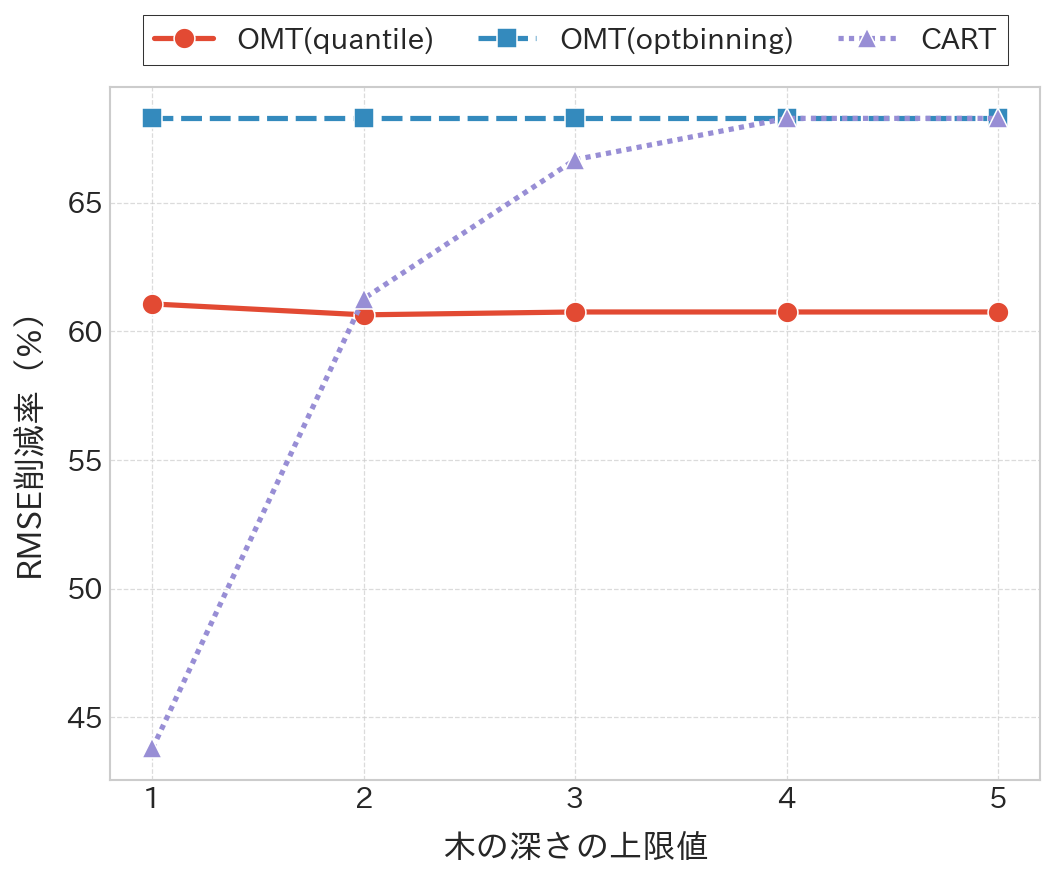

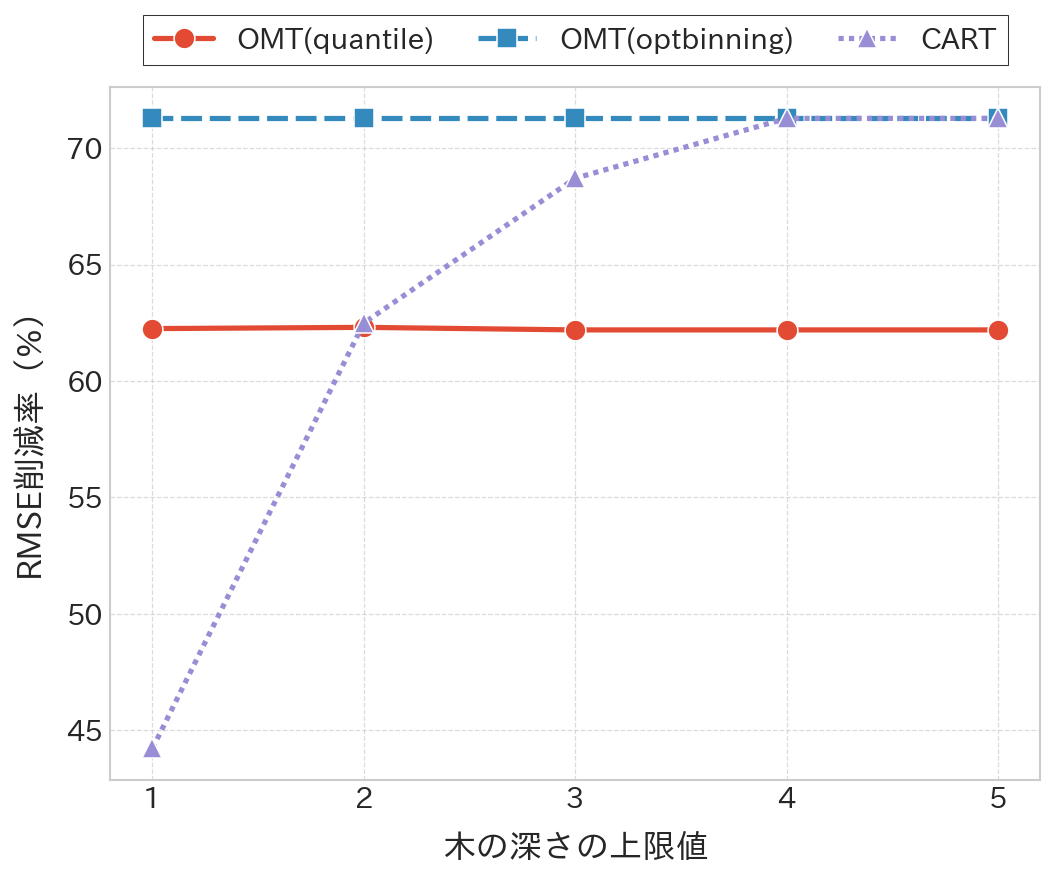

                          問題縮小ロジックの効果サマリー（Proportional / OMT(quantile)）                           
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃      ┃    ルール数（前→後, ┃      制約数（前→後, ┃                    ┃                    ┃                    ┃
┃ 深さ ┃            削減率） ┃            削減率） ┃ 計算時間（縮小後） ┃ 計算時間（縮小前） ┃ 高速化（縮小前/後… ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│    1 │       34→34（0.0%） │ 50000→4373（91.3%） │             0.1310 │             0.6810 │              5.20x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    2 │     438→438（0.0%） │ 50000→4373（91.3%） │             2.0820 │             3.3160 │              1.59x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    3 │   1637→1637（0.0%） │ 50000→4373（91.3%） │             5.3310 │            18.5540 │              3.48x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    4 │   2432→2432（0.0%） │ 50000→4373（91.3%） │             6.5970 │            22.2720 │              3.38x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    5 │   2510→2510（0.0%） │ 50000→4373（91.3%） │             6.0660 │            22.0840 │              3.64x │
└──────┴─────────────────────┴─────────────────────┴────────────────────┴────────────────────┴────────────────────┘

                         問題縮小ロジックの効果サマリー（Proportional / OMT(optbinning)）                          
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃      ┃    ルール数（前→後, ┃      制約数（前→後, ┃                    ┃                    ┃                    ┃
┃ 深さ ┃            削減率） ┃            削減率） ┃ 計算時間（縮小後） ┃ 計算時間（縮小前） ┃ 高速化（縮小前/後… ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│    1 │     137→137（0.0%） │   50000→32（99.9%） │             0.0000 │             1.6250 │                  - │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    2 │     362→362（0.0%） │   50000→32（99.9%） │             0.0160 │             2.5510 │            159.44x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    3 │     362→362（0.0%） │   50000→32（99.9%） │             0.0220 │             2.7620 │            125.55x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    4 │     362→362（0.0%） │   50000→32（99.9%） │             0.0340 │             2.7500 │             80.88x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    5 │     362→362（0.0%） │   50000→32（99.9%） │             0.0210 │             2.7540 │            131.14x │
└──────┴─────────────────────┴─────────────────────┴────────────────────┴────────────────────┴────────────────────┘

                             問題縮小ロジックの効果サマリー（Optimal / OMT(quantile)）                             
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃      ┃    ルール数（前→後, ┃      制約数（前→後, ┃                    ┃                    ┃                    ┃
┃ 深さ ┃            削減率） ┃            削減率） ┃ 計算時間（縮小後） ┃ 計算時間（縮小前） ┃ 高速化（縮小前/後… ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│    1 │       34→34（0.0%） │ 50000→4373（91.3%） │             0.1370 │             0.4640 │              3.39x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    2 │     438→438（0.0%） │ 50000→4373（91.3%） │             0.4660 │             2.5430 │              5.46x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    3 │   1637→1637（0.0%） │ 50000→4373（91.3%） │             1.3300 │             5.8650 │              4.41x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    4 │   2432→2432（0.0%） │ 50000→4373（91.3%） │             1.5510 │             7.4830 │              4.82x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    5 │   2510→2510（0.0%） │ 50000→4373（91.3%） │             1.5010 │             6.9160 │              4.61x │
└──────┴─────────────────────┴─────────────────────┴────────────────────┴────────────────────┴────────────────────┘

                            問題縮小ロジックの効果サマリー（Optimal / OMT(optbinning)）                            
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃      ┃    ルール数（前→後, ┃      制約数（前→後, ┃                    ┃                    ┃                    ┃
┃ 深さ ┃            削減率） ┃            削減率） ┃ 計算時間（縮小後） ┃ 計算時間（縮小前） ┃ 高速化（縮小前/後… ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│    1 │     137→137（0.0%） │   50000→32（99.9%） │             0.0200 │             1.5820 │             79.10x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    2 │     362→362（0.0%） │   50000→32（99.9%） │             0.0160 │             3.0430 │            190.19x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    3 │     362→362（0.0%） │   50000→32（99.9%） │             0.0150 │             3.0170 │            201.14x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    4 │     362→362（0.0%） │   50000→32（99.9%） │             0.0150 │             3.0780 │            205.20x │
├──────┼─────────────────────┼─────────────────────┼────────────────────┼────────────────────┼────────────────────┤
│    5 │     362→362（0.0%） │   50000→32（99.9%） │             0.0190 │             3.0260 │            159.26x │
└──────┴─────────────────────┴─────────────────────┴────────────────────┴────────────────────┴────────────────────┘

✅ 図は outputs\customer\100\combined_experiment_results\figures_for_thesis にPNG（300dpi）でも保存しました。

✅ すべての結果を outputs\customer\100\combined_experiment_results に保存しました。

In [13]:
# =============================================================================
#  OMT vs CART：実験 + 卒論向け可視化（完全版）
# =============================================================================

# =============================================================================
# --- 初期設定 ---
# =============================================================================
console = Console()
japanize_matplotlib.japanize()
plt.style.use('seaborn-v0_8-whitegrid')

# 実験パラメータの統一
MAX_DEPTH_LIST = [1, 2, 3, 4, 5]
OMT_STRATEGIES = ['quantile', 'optbinning']
TREE_OUTPUT_DIR = OUTPUT_DIR / "combined_experiment_results"
TREE_OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# =============================================================================
# --- 1. ベースラインRMSEの計算 ---
# =============================================================================
console.print("\n--- [ステップ1] ベースラインRMSEの計算 ---", style="bold cyan")

y_train_true_mean = y_train.mean()
y_test_true_mean = y_test.mean()

RMSE_RANDOM_TRAIN = random.predict(X_train_std, y_train, true_mean=y_train_true_mean)
RMSE_RANDOM_TEST  = random.predict(X_test_std,  y_test,  true_mean=y_test_true_mean)

# =============================================================================
# --- 2. 実験メインループ (OMT & CART) ---
# =============================================================================
all_rrr_results = []        # 精度評価データ用
all_reduction_stats = []    # 問題縮小ロジック（ルール/制約）用
all_time_results = []       # 深さ vs 計算時間（MIP時間のみ）用

console.print("\n--- [ステップ2] OMT vs CART 性能 & 計算量検証開始 ---", style="bold cyan")
start_experiment_time = time.time()

for allocator in ALLOCATION_METHODS:
    allocator_name = allocator.__str__()
    console.rule(f"[bold red]Allocator: {allocator_name}[/bold red]")

    for max_depth in MAX_DEPTH_LIST:
        # ---------------------------------------------------------------------
        # 2a. OMT (quantile / optbinning)
        # ---------------------------------------------------------------------
        for strategy in OMT_STRATEGIES:
            estimator_name_omt = f"OMT({strategy})"
            console.print(f"\n[bold yellow]実行中: {estimator_name_omt}, 深さ={max_depth}[/bold yellow]")

            omt_params = {
                "allocator": allocator,
                "sample_size": SAMPLE_SIZE,
                "binning_strategy": strategy,
                "num_bins": NUM_BINS,
                "max_rules": 2**max(MAX_DEPTH_LIST),
                "max_features_in_rule": max_depth,
                "min_coverage": MIN_COVERAGE,
                "min_samples_in_rule": MIN_SAMPLES_IN_RULE,
                "n_trials": N_TRIALS,
                "random_state": RANDOM_STATE,
                "verbose": True,
                "run_unoptimized_comparison": True,  # 問題縮小前MIP時間も計測
            }
            if strategy == 'optbinning':
                omt_params.update({
                    "optb_max_n_prebins": 20,
                    "optb_min_prebin_size": 0.05,
                    "optb_max_n_bins": 20,
                    "optb_min_mean_diff": 0.00,
                    "optb_max_pvalue": 0.05,
                    "optb_gamma": 0.0,
                    "optb_monotonic_trend": "auto",
                })

            omt = OMTEstimator(**omt_params)

            try:
                omt.fit(df_X_train_original, y_train)

                # --- 精度 (RRR) の計算 ---
                labels_train_unfiltered = omt.labels_
                covered_mask_train = (labels_train_unfiltered != -1)
                y_train_covered = y_train[covered_mask_train]
                labels_train_covered = labels_train_unfiltered[covered_mask_train]

                sample_size_each_cluster = allocator.solve(
                    y_train_covered, labels_train_covered, omt.n_rules_, SAMPLE_SIZE
                )

                train_m = estimate_y_rmse(
                    sample_size_each_cluster, y_train_covered, labels_train_covered,
                    y_train_true_mean, N_TRIALS, RANDOM_STATE
                )
                rrr_train = (1 - (train_m / RMSE_RANDOM_TRAIN)) * 100

                labels_test_unfiltered = omt._assign_labels(df_X_test_original)
                covered_mask_test = (labels_test_unfiltered != -1)
                y_test_covered = y_test[covered_mask_test]
                labels_test_covered = labels_test_unfiltered[covered_mask_test]

                test_m = estimate_y_rmse(
                    sample_size_each_cluster, y_test_covered, labels_test_covered,
                    y_test_true_mean, N_TRIALS, RANDOM_STATE
                )
                rrr_test = (1 - (test_m / RMSE_RANDOM_TEST)) * 100

                all_rrr_results.append({
                    "allocator_name": allocator_name,
                    "estimator_name": estimator_name_omt,
                    "max_depth": max_depth,
                    "rrr_train": rrr_train,
                    "rrr_test": rrr_test
                })

                # --- 計算量（MIP時間は「問題規模縮小後」だけを採用） ---
                stats = omt.reduction_stats_
                mip_opt   = stats.get('mip_computation_time_sec', np.nan)                 # 縮小後MIP
                mip_unopt = stats.get('mip_computation_time_unoptimized_sec', np.nan)     # 縮小前MIP（参考）

                # 深さ vs 計算時間（MIP縮小後）用
                all_time_results.append({
                    "allocator_name": allocator_name,
                    "estimator_name": estimator_name_omt,
                    "max_depth": max_depth,
                    "mip_time_sec": mip_opt,
                })

                # 問題縮小ロジックの効果保存
                all_reduction_stats.append({
                    "allocator_name": allocator_name,
                    "estimator_name": estimator_name_omt,
                    "max_features": max_depth,
                    "rules_before": stats.get("paths_before", np.nan),
                    "rules_after": stats.get("paths_after_var_reduction", np.nan),
                    "constraints_before": stats.get("instances_before", np.nan),
                    "constraints_after": stats.get("instances_after_const_reduction", np.nan),
                    "mip_time_optimized_sec": mip_opt,
                    "mip_time_unoptimized_sec": mip_unopt,
                    "mip_speedup": (mip_unopt / mip_opt) if (mip_opt > 0 and not np.isnan(mip_unopt)) else np.nan
                })

                # 木の画像保存
                tree_filename = TREE_OUTPUT_DIR / f"{allocator_name}_{estimator_name_omt}_depth_{max_depth}.png"
                omt.save_tree_png(filename=str(tree_filename))

                console.print(f"  -> OMT完了 (Test RRR: {rrr_test:.2f}%)", style="green")

            except Exception as e:
                console.print(f"  -> [bold red]OMTエラー: {e}[/bold red]")

        # ---------------------------------------------------------------------
        # 2b. CART の実行（精度のみ）
        # ---------------------------------------------------------------------
        try:
            cart = CARTEstimator(
                allocator=allocator, sample_size=SAMPLE_SIZE, n_trials=N_TRIALS,
                max_depth=max_depth, random_state=RANDOM_STATE, min_samples_leaf=MIN_SAMPLES_IN_RULE
            )
            cart.fit(df_X_train_encoded, y_train)

            c_train_m = cart.predict(df_X_train_encoded, y_train, true_mean=y_train_true_mean)
            c_test_m  = cart.predict(df_X_test_encoded,  y_test,  true_mean=y_test_true_mean)

            rrr_train_c = (1 - (c_train_m / RMSE_RANDOM_TRAIN)) * 100
            rrr_test_c  = (1 - (c_test_m / RMSE_RANDOM_TEST))  * 100

            all_rrr_results.append({
                "allocator_name": allocator_name,
                "estimator_name": "CART",
                "max_depth": max_depth,
                "rrr_train": rrr_train_c,
                "rrr_test": rrr_test_c
            })

            tree_filename_cart = TREE_OUTPUT_DIR / f"{allocator_name}_CART_depth_{max_depth}.png"
            cart.save_tree_png(feature_names=columns_list_encoded, filename=str(tree_filename_cart))

            console.print(f"  -> CART完了 (Test RRR: {rrr_test_c:.2f}%)", style="green")

        except Exception as e:
            console.print(f"  -> [bold red]CARTエラー: {e}[/bold red]")


# =============================================================================
# 3. 結果の可視化（卒論・論文投稿向け：テスト精度・モノクロ配慮版）
# =============================================================================
console.print(f"\n--- [ステップ3] 論文用図表の作成を開始します ---", style="bold cyan")

# 結果の整形
rrr_df = pd.DataFrame(all_rrr_results)
reduction_df = pd.DataFrame(all_reduction_stats)
time_df = pd.DataFrame(all_time_results)

# 論文用の日本語マッピング
allocator_name_map = {
    "Proportional": "比例配分",
    "Optimal": "最適配分",
}

# =============================================================================
# --- 卒論・論文向けのスタイル設定 ---
# =============================================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "IPAexGothic", 
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "axes.labelpad": 10,
    "lines.linewidth": 2.5,
})

FIG_DIR = TREE_OUTPUT_DIR / "figures_for_thesis"
FIG_DIR.mkdir(exist_ok=True, parents=True)

# 手法ごとのマーカー設定（モノクロ印刷対応）
marker_map = {
    "OMT(quantile)": "o",   # 円
    "OMT(optbinning)": "s", # 四角
    "CART": "^"             # 三角
}

# -------------------------------------------------------------------------
# 3a. 木の深さに対する RMSE削減率（RRR）: テストデータのみ
# -------------------------------------------------------------------------
for alloc_raw, alloc_jp in allocator_name_map.items():
    # 該当する配分手法のテストデータのみ抽出
    current_df = rrr_df[rrr_df['allocator_name'] == alloc_raw].copy()
    
    # 図の作成
    fig, ax = plt.subplots(figsize=(8, 6))

    # 折れ線グラフの描画
    # hueとstyleを同時に指定し、markersに辞書を渡すことで手法ごとに形状を固定
    sns.lineplot(
        data=current_df,
        x='max_depth',
        y='rrr_test',
        hue='estimator_name',
        style='estimator_name',
        markers=marker_map,
        markersize=10,
        ax=ax
    )

    # 軸・ラベル設定（タイトルは無し）
    ax.set_xlabel("木の深さの上限値")
    ax.set_ylabel("RMSE削減率（%）")
    ax.set_xticks(MAX_DEPTH_LIST)
    
    # グリッド設定
    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)

    # 凡例を上部に横並びで配置（論文の構成に合わせて調整可能）
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles,
        labels=labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.01), # 図のすぐ上
        ncol=3,                     # 3手法を横に並べる
        frameon=True,
        edgecolor="black",
        fancybox=False,
        columnspacing=1.5,
    )

    outpath = FIG_DIR / f"rrr_vs_depth_test_{alloc_raw}.png"
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# -------------------------------------------------------------------------
# 3b. 問題縮小ロジックの効果の表（Rich Table） - コンソール確認用
# -------------------------------------------------------------------------
for allocator_name in reduction_df['allocator_name'].unique():
    df_sub_alloc = reduction_df[reduction_df['allocator_name'] == allocator_name].copy()

    for estimator_name in df_sub_alloc['estimator_name'].unique():
        df_sub = df_sub_alloc[df_sub_alloc['estimator_name'] == estimator_name].copy()
        df_sub = df_sub.sort_values("max_features")

        table = Table(
            title=f"問題縮小ロジックの効果サマリー（{allocator_name} / {estimator_name}）",
            show_lines=True
        )
        table.add_column("深さ", justify="right")
        table.add_column("ルール数（前→後, 削減率）", justify="right")
        table.add_column("制約数（前→後, 削減率）", justify="right")
        table.add_column("計算時間（縮小後）[s]", justify="right")
        table.add_column("計算時間（縮小前）[s]", justify="right")
        table.add_column("高速化（縮小前/後）", justify="right")

        for _, row in df_sub.iterrows():
            rb, ra = row['rules_before'], row['rules_after']
            cb, ca = row['constraints_before'], row['constraints_after']

            rules_red = (1 - ra / rb) * 100 if (rb and rb > 0 and not np.isnan(ra)) else np.nan
            cons_red  = (1 - ca / cb) * 100 if (cb and cb > 0 and not np.isnan(ca)) else np.nan

            table.add_row(
                str(int(row['max_features'])),
                f"{rb:.0f}→{ra:.0f}（{rules_red:.1f}%）" if not np.isnan(rules_red) else f"{rb:.0f}→{ra:.0f}（-）",
                f"{cb:.0f}→{ca:.0f}（{cons_red:.1f}%）"  if not np.isnan(cons_red)  else f"{cb:.0f}→{ca:.0f}（-）",
                f"{row['mip_time_optimized_sec']:.4f}",
                f"{row['mip_time_unoptimized_sec']:.4f}",
                f"{row['mip_speedup']:.2f}x" if not np.isnan(row['mip_speedup']) else "-"
            )
        console.print(table)

console.print(f"\n✅ 図は {FIG_DIR} にPNG（300dpi）でも保存しました。", style="bold green")

# =============================================================================
# --- 4. CSV保存 ---
# =============================================================================
rrr_df.to_csv(TREE_OUTPUT_DIR / "rrr_comparison_results.csv", index=False)
reduction_df.to_csv(TREE_OUTPUT_DIR / "computational_reduction_results.csv", index=False)
time_df.to_csv(TREE_OUTPUT_DIR / "mip_time_vs_depth_results.csv", index=False)

console.print(f"\n✅ すべての結果を {TREE_OUTPUT_DIR} に保存しました。", style="bold green")
